## N-Queens
- *Luan Carlos dos Santos*
---

##### Importações

In [1714]:
import random
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
import time

##### Função Objetivo

In [1715]:
def funcao_objetivo(S):
  dp = []
  dn = []
  for i in range(len(S)):
    dp.append(i - S[i])
    dn.append(i + S[i])
  freq_dp = Counter(dp)
  freq_dn = Counter(dn)
  conflitos_dp = sum(qtd * (qtd - 1) // 2 for qtd in freq_dp.values() if qtd > 1)
  conflitos_dn = sum(qtd * (qtd - 1) // 2 for qtd in freq_dn.values() if qtd > 1)
  fitness = conflitos_dp + conflitos_dn
  return fitness

##### Função de Plot Gráfico de Convergência

In [1716]:
def plt_grafico_convergencia(historico_conflitos, historico_rodadas, n_rainhas):
  plt.figure(figsize=(12, 6))

  # Plota a evolução dos conflitos
  plt.plot(historico_rodadas, historico_conflitos, linestyle='-', linewidth=0.6, color="#00FF00", label='Conflitos Atuais')

  # Adiciona a linha horizontal de meta em Y=0
  plt.axhline(y=0, color='red', linestyle='-', linewidth=0.4, label='Meta (Zero Conflitos)')

  # Customizações estéticas para o relatório
  plt.title(f'Evolução do Número de Conflitos por Iteração ({n_rainhas} Rainhas)', fontsize=14, fontweight='bold')
  plt.xlabel('Rodadas (Iterações)', fontsize=12)
  plt.ylabel('Número de Conflitos', fontsize=12)

  # Define os limites do gráfico para ficar bem enquadrado
  plt.xlim(0, max(historico_rodadas) * 1.05)
  plt.ylim(-1, max(historico_conflitos) * 1.1)

  plt.grid(True, linestyle=':', alpha=0.6)
  plt.legend(loc='upper right', fontsize=11)
  plt.show()

### Inicializações da Busca

In [1717]:

#Parâmetros
n = 100
max_rodadas = 700
n_rodadas_off = 50
n_vizinhos = 150

#Analises
seed_demonstracao = 42
random.seed(seed_demonstracao)
rejeicoes = 0
moves = 0

# Estruturas e variáveis
solucao_atual = random.sample(range(0, n), n)
n_conflitos = funcao_objetivo(solucao_atual)

matriz_tabu = np.zeros((n,n), dtype=int)
np.fill_diagonal(matriz_tabu, -1)

# Resultados
otima_solucao = solucao_atual.copy()
otima_fitness = n_conflitos
hist_conflitos = [n_conflitos]
hist_rodadas = [0]
rodada = 1

### Busca Tabu TS - Tabu Search

In [1718]:
inicio_tempo = time.time()
while rodada < max_rodadas:
  top_vizinho_rodada = None
  top_fitness_rodada = float('inf')
  top_par_pos_rodada = None  
  for i in range(n_vizinhos):
    par_pos = sorted(random.sample(range(0, n), 2))
    p1, p2 = par_pos[0], par_pos[1]
    
    solucao_atual[p1], solucao_atual[p2] = solucao_atual[p2], solucao_atual[p1]
    
    fitness_atual = funcao_objetivo(solucao_atual)

    tabu = rodada <= matriz_tabu[p1, p2]
    aspiracao = fitness_atual < otima_fitness
    if not tabu or aspiracao:
      if fitness_atual < top_fitness_rodada:
        top_fitness_rodada = fitness_atual
        top_vizinho_rodada = solucao_atual.copy()
        top_par_pos_rodada = par_pos
    else:
      rejeicoes+=1    
    solucao_atual[p1], solucao_atual[p2] = solucao_atual[p2], solucao_atual[p1]
    moves+=1
  if top_vizinho_rodada is not None:
    solucao_atual = top_vizinho_rodada.copy()
    n_conflitos = top_fitness_rodada

    p1, p2 = top_par_pos_rodada[0], top_par_pos_rodada[1]
    matriz_tabu[p1, p2] = rodada + n_rodadas_off
    matriz_tabu[p2, p1] = rodada + n_rodadas_off
  
    if n_conflitos < otima_fitness:
      otima_solucao = solucao_atual.copy()
      otima_fitness = n_conflitos
  hist_conflitos.append(otima_fitness)
  hist_rodadas.append(rodada)
  rodada+=1
  if n_conflitos == 0:
    break
tempo_total = time.time() - inicio_tempo


### Análises

In [1719]:
if rodada == max_rodadas:
  print(f'Máximo de Iterações Atingido![{rodada}/{max_rodadas}], em {tempo_total:.2f}s!')
  print('Paramêtros:')
  print(f'  - Número de Rainhas             : {n}')
  print(f'  - Penalização(n_rodadas_off)    : {n_rodadas_off}')
  print(f'  - Número de Vizinhos            : {n_vizinhos}')
  print(f'  - Número de Conflitos           : {n_conflitos}')
  print('Estatísticas:')
  print(f'  - Total de rejeições            : {rejeicoes}')
  print(f'  - Quantidade de moves(swaps)    : {moves}')
  print(f'  - Percentual de Rejeição        : {rejeicoes/moves*100:.2f}%')
  plt_grafico_convergencia(hist_conflitos, hist_rodadas, n)
if otima_fitness == 0:
  print(60*'-')
  print(f'   SOLUÇÃO ÓTIMA ENCONTRADA! Rodada {rodada} de {max_rodadas}, em {tempo_total:.2f}s!')
  print(60*'-')
  print(f'Solução: {otima_solucao}')
  print('Paramêtros:')
  print(f'  - Número de Rainhas             : {n}')
  print(f'  - Penalização(n_rodadas_off)    : {n_rodadas_off}')
  print(f'  - Número de Vizinhos            : {n_vizinhos}')
  print(f'  - Número de Conflitos           : {n_conflitos}')
  print('Estatísticas:')
  print(f'  - Total de rejeições            : {rejeicoes}')
  print(f'  - Quantidade de moves(swaps)    : {moves}')
  print(f'  - Percentual de Rejeição        : {rejeicoes/moves*100:.2f}%')

------------------------------------------------------------
   SOLUÇÃO ÓTIMA ENCONTRADA! Rodada 51 de 700, em 0.20s!
------------------------------------------------------------
Solução: [25, 45, 34, 94, 52, 42, 28, 5, 79, 86, 27, 30, 14, 8, 41, 97, 26, 69, 60, 64, 98, 81, 71, 84, 89, 54, 18, 57, 32, 35, 20, 99, 43, 56, 19, 70, 67, 6, 38, 1, 33, 22, 68, 58, 95, 16, 24, 2, 4, 31, 93, 23, 88, 61, 66, 3, 55, 90, 7, 73, 12, 85, 0, 29, 44, 59, 63, 74, 47, 53, 91, 87, 13, 76, 49, 80, 96, 51, 21, 11, 37, 17, 9, 48, 75, 72, 62, 46, 39, 36, 78, 15, 50, 82, 77, 65, 92, 83, 40, 10]
Paramêtros:
  - Número de Rainhas             : 100
  - Penalização(n_rodadas_off)    : 50
  - Número de Vizinhos            : 150
  - Número de Conflitos           : 0
Estatísticas:
  - Total de rejeições            : 35
  - Quantidade de moves(swaps)    : 7500
  - Percentual de Rejeição        : 0.47%


### Gráfico de Convergência

Ótima solução encontrada na rodada [51/700], em 0.20s!


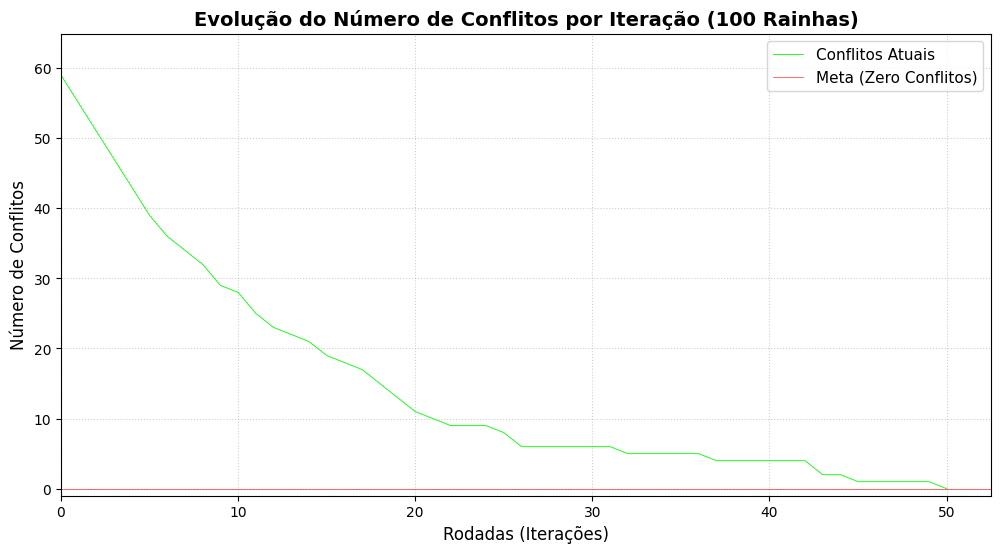

In [1720]:
if rodada == max_rodadas:
  print(f'Máximo de Iterações Atingido![{rodada}/{max_rodadas}], em {tempo_total:.2f}s!')
  plt_grafico_convergencia(hist_conflitos, hist_rodadas, n)
if otima_fitness == 0:
  print(f'Ótima solução encontrada na rodada [{rodada}/{max_rodadas}], em {tempo_total:.2f}s!')
  plt_grafico_convergencia(hist_conflitos, hist_rodadas, n)